# Overview

This notebook builds and evaluates a **distance‑3 planar surface code** in Qiskit.

- Construct the d=3 layout (data qubits and stabilizer ancillas) and circuits for **single‑round** and **k‑round (space–time)** syndrome extraction.
- Define a simple depolarising **noise model** with readout error.
- Implement lightweight **MWPM decoders**: 2D for single‑round and 3D (space–time) for time‑differenced syndromes.
- Run **Monte‑Carlo sweeps** over physical error rate and compare logical‑X / logical‑Z failure rates.
- Generate a **comparison plot**: single‑round vs space–time decoding.

## Reproduce

- Python ≥ 3.9
- Install deps:
```bash
pip install qiskit networkx numpy matplotlib
```
- Then run this notebook top‑to‑bottom. For a quick demo, keep the defaults; for a longer run, increase `shots` in the **Simulation** section.


In [9]:
# Import dependencies

import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from qec.geometry import (
    d_idx,
    PLAQS,
    ANC_POS,
    TOP_Y,
    BOT_Y,
    LEFT_X,
    RIGHT_X,
    GRID_SPAN,
    manhattan,
)

from qec.noise import depol_noise_model

from qec.simulation import compare_single_vs_spacetime

from qec.circuit import one_round_surface_d3

In [10]:
# d=3 planar code: 3x3 data qubits, 4 X- and 4 Z-stabilizers (ancillas)

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import depolarizing_error, ReadoutError
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Table of Contents

- [1. Data Structure](#data)
- [2. Syndrome Extraction](#syndrome)
- [3. Depolarising Noise Model](#noise)
- [4. MWPM Decoder Scaffold](#decoder)
- [5. Evaluation Metrics](#eval)
- [6. Simulations](#sim)

# 2. Syndrome Extraction
<a id="syndrome"></a>

Syndrome Extraction (space-time encdoing of k rounds) 

In [11]:
# Space-time encoding ensures each round’s ancilla starts clean; XOR of consecutive rounds isolates whether 
# changes came from data errors (flip persists in space) or measurement errors (flip only in time).

# 4. MWPM Decoder Scaffold
<a id="decoder"></a>

In [12]:
# Minimum-Weight Perfect Matching tries to pair up all defects with the shortest possible correction paths.
# Each defect is represented as a node in a graph and edge weights = “cost” (distance) between two defects.
# If have an odd number of defects, add a boundary node (B).

# e.g. (a0, a3) — connect defect 0 to defect 3 with a correction chain.
#      (a2, B) — connect defect 2 to the nearest boundary.

In [13]:
# Pseudocode
# INPUT: Zbits from last round (4 bits, one per Z plaquette)
# 1. Find defects = indices of '1' bits
# 2. Make graph G, nodes = defect labels ('a0', 'a1', ...)
# 3. If odd number of defects → add boundary node 'B'
# 4. Connect all pairs with edges weighted by distance
# 5. Run MWPM → get matched pairs
# 6. These pairs = correction paths to apply

# 6. Simulations
<a id="sim"></a>

1 Round Syndrome Extraction Simulation

In [14]:
sim = AerSimulator()
basis = ['id','rz','sx','x','h','cx','measure']

qc = one_round_surface_d3()
tc = transpile(qc, sim, basis_gates=basis, optimization_level=1)

noise = depol_noise_model(p1=0.01, ro=0.01)   # tweak p1 to see more/less defects
res = sim.run(tc, shots=2000, noise_model=noise).result()
counts = res.get_counts()

print("num distinct syndromes:", len(counts))
list(counts.items())[:5]

# quick parse: convert bitstring 'xxxxzzzz' -> (X_syndrome, Z_syndrome)
def parse_syndrome(bitstr, n_x=4):
    s = bitstr.replace(' ', '')  # just in case
    s = s[::-1]
    return s[:n_x], s[n_x:]

# show top-5 most common syndromes
top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
for bits, n in top:
    xs, zs = parse_syndrome(bits, 4)
    print(f"{bits:>10}  shots={n:4d}   X={xs}  Z={zs}")

num distinct syndromes: 256
  01001100  shots=  16   X=0011  Z=0010
  11011001  shots=  15   X=1001  Z=1011
  10100110  shots=  15   X=0110  Z=0101
  00111100  shots=  14   X=0011  Z=1100
  11101000  shots=  14   X=0001  Z=0111


K Rounds Simulation (comparing single round vs space-time syndrome extraction)

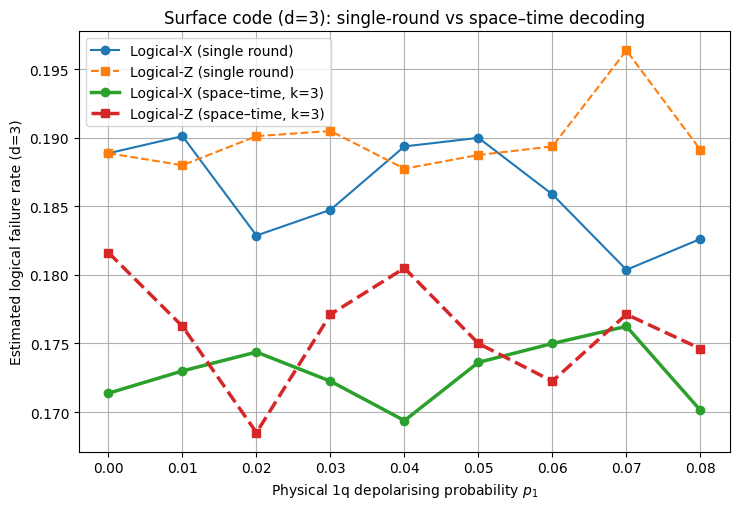

In [15]:
# run the comparison
p_vals = np.linspace(0.0, 0.08, 9)
ps, pLX_1, pLZ_1, pLX_ST, pLZ_ST = compare_single_vs_spacetime(
    p_vals, k_space_time=3, k_single=1, shots=8000, ro=0.01
)

# plot (optionally save)
save_path = None  # e.g., "image-results/1.png"
plt.figure(figsize=(7.5,5.2))
plt.plot(ps, pLX_1, 'o-',  label='Logical-X (single round)')
plt.plot(ps, pLZ_1, 's--', label='Logical-Z (single round)')
plt.plot(ps, pLX_ST, 'o-',  linewidth=2.5, label='Logical-X (space–time, k=3)')
plt.plot(ps, pLZ_ST, 's--', linewidth=2.5, label='Logical-Z (space–time, k=3)')
plt.xlabel('Physical 1q depolarising probability $p_1$')
plt.ylabel('Estimated logical failure rate (d=3)')
plt.title('Surface code (d=3): single-round vs space–time decoding')
plt.grid(True); plt.legend(); plt.tight_layout()

if save_path:
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved to {save_path}")

plt.show()